# TS2: DFT y FFT
Función que calcula la DFT de una señal digital por definición. Luego se compara con la FFT de Numpy.





In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# DFT
def mi_dft(xx):
  N = len(xx)
  n = np.arange(start=0, stop=N).reshape(1,N)
  k = n.copy().reshape(N,1)

  xx_T = xx.reshape(1,N)
  e_ = np.exp(-1j * 2 * np.pi * n * k /N)
  X_dft = np.dot(xx_T, e_)  # Producto interno: 1xN * NxN = 1xN
  return X_dft.reshape(N,1)

### Ejemplo de uso con fs = 8 Hz y N = 8

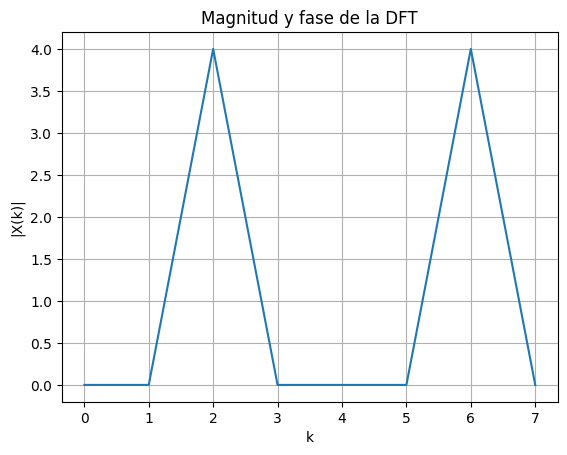

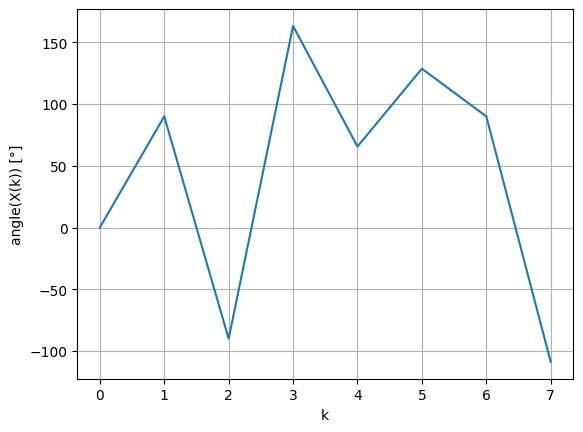

In [3]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
  tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
  xx = dc + vmax * np.sin( 2*np.pi * ff * tt + ph )
  return tt, xx.reshape(N,1)

def plot_amp_angle(x_amp, x_ang, name):
  plt.figure()
  plt.title("Magnitud y fase de la DFT")
  plt.plot(x_amp)
  plt.xlabel("k")
  plt.ylabel(f"|{name}(k)|")
  plt.grid()
  plt.show()

  plt.figure()
  plt.plot(x_ang)
  plt.xlabel("k")
  plt.ylabel(f"angle({name}(k)) [°]")
  plt.grid()
  plt.show()

fs = 8 # Hz
N = fs
fx = 2*fs/N  # Hz
ax = 1  # V
dx = 0  # V
px = 0  # rad
tt, xx = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)

X_mi_dft = mi_dft(xx)
X_mi_dft_abs = np.abs(X_mi_dft)
X_mi_dft_ang = np.rad2deg(np.angle(X_mi_dft))

plot_amp_angle(X_mi_dft_abs, X_mi_dft_ang, "X")

### Senoidal de 2 Hz, 1V, fase 0
- Se observan dos deltas de Kronecker en los índices k=2 y k=6, de valor 4 por estar escalados N veces.
- La resolución espectral es Δf = fs/N = 1 Hz, por lo que la primer delta en k=2 se debe a la frecuencia de la señal.
- La frecuencia de Nyquist es de 4 Hz -> k=4 que delimita el eje de simetría; esto genera la segunda delta que debe ser el conjugado, en k=6.
- En fase la primera delta está en -90° y la segunda en +90°. Si la fase de la senoidal pasara a ser 180° esto se vería invertido.

## Usando el módulo FFT de Numpy

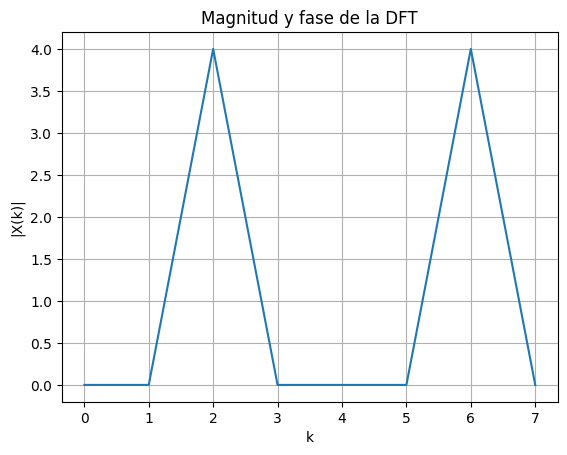

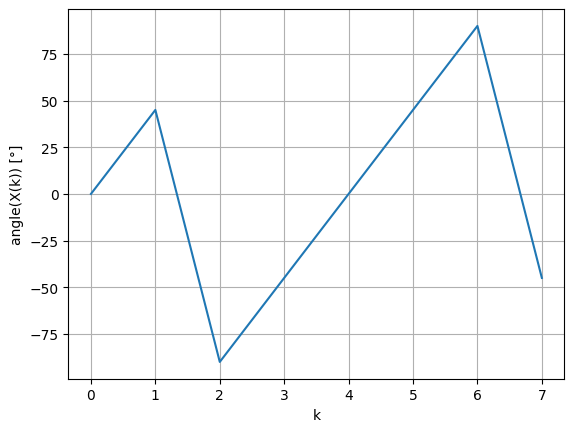

In [4]:
X_fft = np.fft.fft(xx, axis=0)
X_fft_abs = np.abs(X_fft)
X_fft_ang = np.rad2deg(np.angle(X_fft))

plot_amp_angle(X_fft_abs, X_fft_ang, "X")

- No se observan cambios en el resultado (magnitud y fase en n=2 y n=6).

## DFT de una señal aleatoria

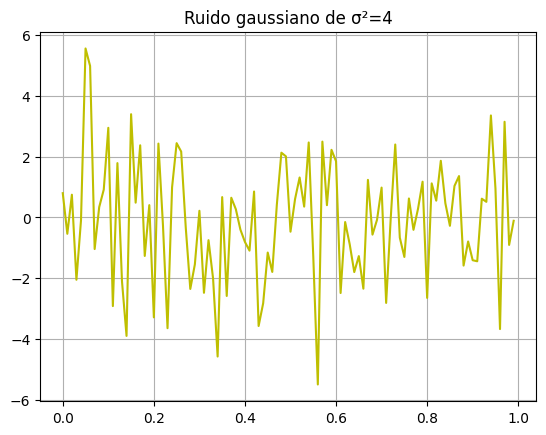

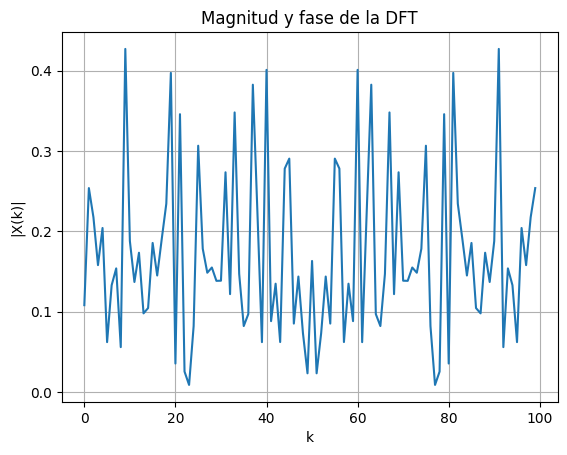

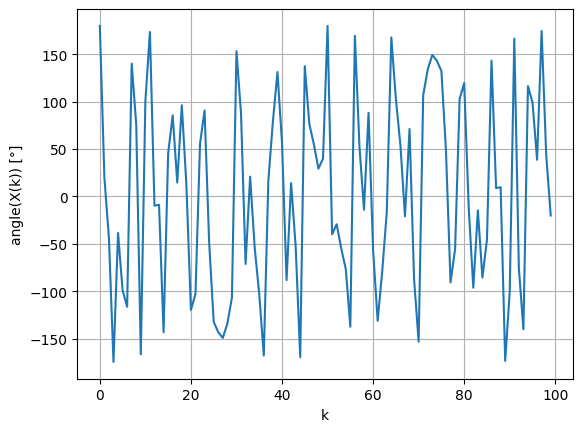

Potencia total: 4.016863709516713


In [14]:
def mi_funcion_ruido(sigma=1, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = np.random.normal(0, sigma, len(tt))
    return tt, xx.reshape(N,1)

fs = 100 # Hz
N = fs  # Resolución espectral fs/N = 1Hz, tiempo de simulación 1seg

t, x_n = mi_funcion_ruido(sigma=2, nn=N, fs=fs)
plt.figure()
plt.plot(t, x_n, '-', color = 'y')
plt.title("Ruido gaussiano de σ²=4")
plt.grid()
plt.show()

X_mi_dft = mi_dft(x_n)/N
X_mi_dft_abs = np.abs(X_mi_dft)
X_mi_dft_ang = np.rad2deg(np.angle(X_mi_dft))

plot_amp_angle(X_mi_dft_abs, X_mi_dft_ang, "X")
print(f"Potencia total: {np.sum(X_mi_dft_abs**2)}")

- Se puede ver que para una señal aleatoria todas las frecuencias tienen un valor de magnitud distinto a cero, es decir, todas las frecuencias tienen energía.
- La fase es aleatoria en todo el espectro.
- La potencia de la señal es σ² = 4.